In [1]:
import pandas as pd
import glob, os, json
import matplotlib.pyplot as plt

BASE_DIR = "../raw_csv/type5_Vbr_statistics"
OUT_DIR  = "../results"
PLOT_DIR = "../results/plots"
os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(PLOT_DIR, exist_ok=True)

files = glob.glob(os.path.join(BASE_DIR, "*.csv"))
print("Found:", files)
if not files:
    raise RuntimeError("No CSV files found in type5_Vbr_statistics")

rows = []
for f in files:
    df = pd.read_csv(f)

    # clean column names
    df.columns = [c.strip() for c in df.columns]

    # accept Vrb or Vbr
    if "Vrb" in df.columns and "Vbr" not in df.columns:
        df = df.rename(columns={"Vrb": "Vbr"})
    elif "Vbr" not in df.columns and "Vrb" not in df.columns:
        raise RuntimeError(f"Neither Vrb nor Vbr column found in {os.path.basename(f)}")

    # ensure HTL exists (case-insensitive fallback)
    if "HTL" not in df.columns:
        # try to find a column that looks like HTL
        htl_like = [c for c in df.columns if c.lower() == "htl"]
        if htl_like:
            df = df.rename(columns={htl_like[0]: "HTL"})
        else:
            raise RuntimeError(f"HTL column not found in {os.path.basename(f)}")

    fname = os.path.basename(f)
    if "Ag" in fname:
        df["Electrode"] = "Ag"
    elif "Au" in fname:
        df["Electrode"] = "Au"
    else:
        df["Electrode"] = "Unknown"

    df["SourceFile"] = fname
    rows.append(df)

type5_df = pd.concat(rows, ignore_index=True)

# numeric cleanup (handles strings, blanks)
type5_df["Vbr"] = pd.to_numeric(type5_df["Vbr"], errors="coerce")
type5_df = type5_df.dropna(subset=["Vbr", "HTL"]).reset_index(drop=True)

# PerovAI tags
type5_df["Type"] = "Type5"
type5_df["Week"] = 8
type5_df["DatasetRole"] = "Statistics"

print(type5_df.head())
print("Rows:", len(type5_df), "HTLs:", type5_df["HTL"].nunique(), "Electrodes:", type5_df["Electrode"].unique())

Found: ['../raw_csv/type5_Vbr_statistics\\Vbr_stats_Ag.csv', '../raw_csv/type5_Vbr_statistics\\Vbr_stats_Au.csv']
    Vbr        HTL Electrode        SourceFile   Type  Week DatasetRole
0 -0.48  MeO-2PACz        Ag  Vbr_stats_Ag.csv  Type5     8  Statistics
1 -0.48  MeO-2PACz        Ag  Vbr_stats_Ag.csv  Type5     8  Statistics
2 -0.46  MeO-2PACz        Ag  Vbr_stats_Ag.csv  Type5     8  Statistics
3 -0.44  MeO-2PACz        Ag  Vbr_stats_Ag.csv  Type5     8  Statistics
4 -0.53  MeO-2PACz        Ag  Vbr_stats_Ag.csv  Type5     8  Statistics
Rows: 263 HTLs: 5 Electrodes: ['Ag' 'Au']


In [2]:
out_csv = os.path.join(OUT_DIR, "perovai_type5_statistics_week08.csv")
type5_df.to_csv(out_csv, index=False)
print("Saved:", out_csv)

meta = {
    "dataset": "perovai_type5_statistics_week08",
    "description": "Vbr/Vrb statistics by HTL and electrode (Ag/Au), Week08",
    "week": 8,
    "type": "Type5",
    "columns": type5_df.columns.tolist(),
    "n_rows": int(len(type5_df)),
    "HTLs": sorted(type5_df["HTL"].unique().tolist()),
    "electrodes": sorted(type5_df["Electrode"].unique().tolist()),
    "source_files": sorted(type5_df["SourceFile"].unique().tolist()),
    "units": {"Vbr": "V", "HTL": "text"}
}

out_json = os.path.join(OUT_DIR, "perovai_type5_statistics_week08_metadata.json")
with open(out_json, "w") as f:
    json.dump(meta, f, indent=2)
print("Saved:", out_json)


Saved: ../results\perovai_type5_statistics_week08.csv
Saved: ../results\perovai_type5_statistics_week08_metadata.json


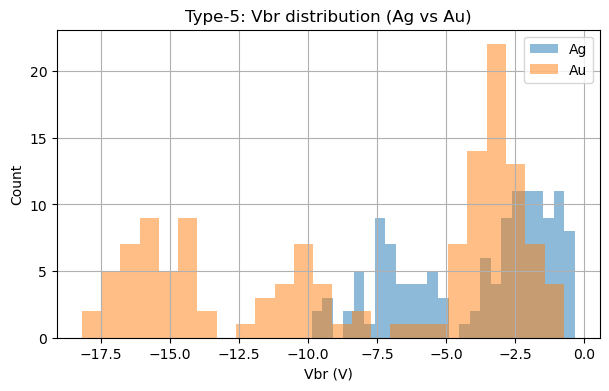

In [5]:
fig = plt.figure(figsize=(7,4))
for elec, g in type5_df.groupby("Electrode"):
    plt.hist(g["Vbr"], bins=25, alpha=0.5, label=elec)

plt.xlabel("Vbr (V)")
plt.ylabel("Count")
plt.title("Type‑5: Vbr distribution (Ag vs Au)")
plt.legend()
plt.grid(True)

fig.savefig(os.path.join(PLOT_DIR, "type5_vbr_hist_ag_vs_au.png"), dpi=300, bbox_inches="tight")
fig.savefig(os.path.join(PLOT_DIR, "type5_vbr_hist_ag_vs_au.pdf"), bbox_inches="tight")
plt.show()

<Figure size 900x400 with 0 Axes>

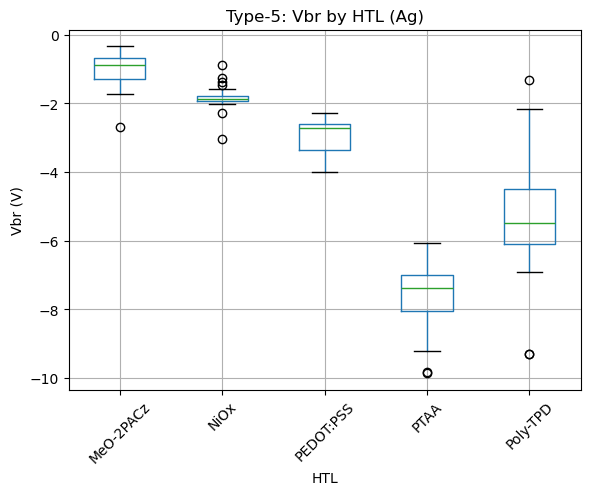

<Figure size 900x400 with 0 Axes>

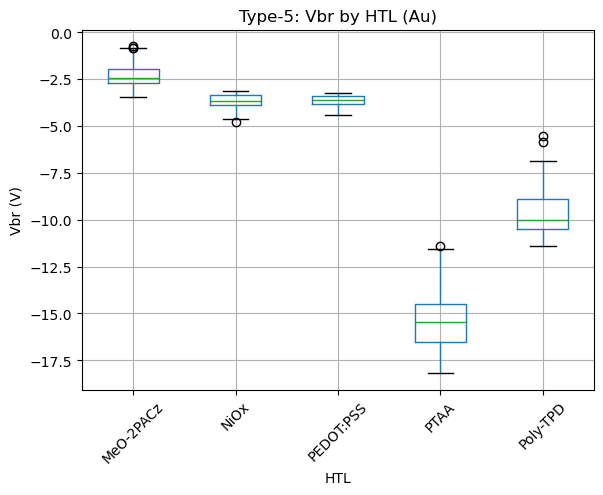

In [6]:
for elec in sorted(type5_df["Electrode"].unique()):
    sub = type5_df[type5_df["Electrode"] == elec].copy()
    if sub.empty: 
        continue

    fig = plt.figure(figsize=(9,4))
    sub.boxplot(column="Vbr", by="HTL", rot=45)
    plt.ylabel("Vbr (V)")
    plt.title(f"Type‑5: Vbr by HTL ({elec})")
    plt.suptitle("")
    plt.grid(True)

    fig.savefig(os.path.join(PLOT_DIR, f"type5_vbr_box_by_htl_{elec}.png"), dpi=300, bbox_inches="tight")
    fig.savefig(os.path.join(PLOT_DIR, f"type5_vbr_box_by_htl_{elec}.pdf"), bbox_inches="tight")
    plt.show()

In [7]:
print("Electrode values:", type5_df["Electrode"].unique())
print("HTL values:", type5_df["HTL"].unique())
print("Number of rows:", len(type5_df))

Electrode values: ['Ag' 'Au']
HTL values: ['MeO-2PACz' 'NiOx' 'PEDOT:PSS' 'Poly-TPD' 'PTAA']
Number of rows: 263


In [8]:
type5_df["Electrode"] = type5_df["Electrode"].astype(str).str.strip()
type5_df["HTL"] = type5_df["HTL"].astype(str).str.strip()

In [9]:
print(type5_df["Electrode"].unique())
print(type5_df["HTL"].unique())

['Ag' 'Au']
['MeO-2PACz' 'NiOx' 'PEDOT:PSS' 'Poly-TPD' 'PTAA']


C:\Users\Mazhar\AppData\Local\Temp\ipykernel_3484\223785522.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(htl_groups, labels=htl_labels, showfliers=True)


Saved: ../results/plots\type5_vbr_box_by_htl_Ag.png
Saved: ../results/plots\type5_vbr_box_by_htl_Ag.pdf


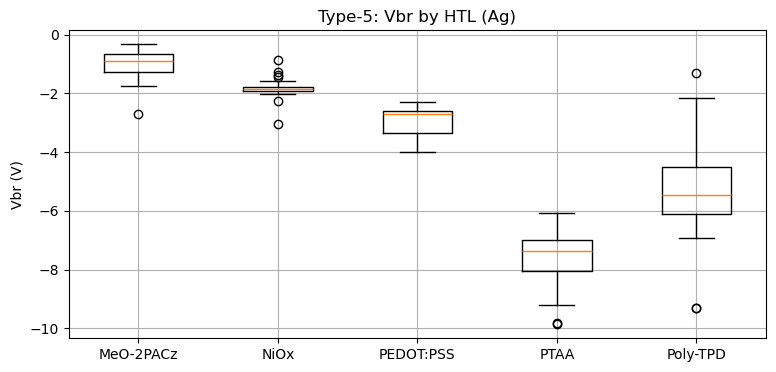

C:\Users\Mazhar\AppData\Local\Temp\ipykernel_3484\223785522.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(htl_groups, labels=htl_labels, showfliers=True)


Saved: ../results/plots\type5_vbr_box_by_htl_Au.png
Saved: ../results/plots\type5_vbr_box_by_htl_Au.pdf


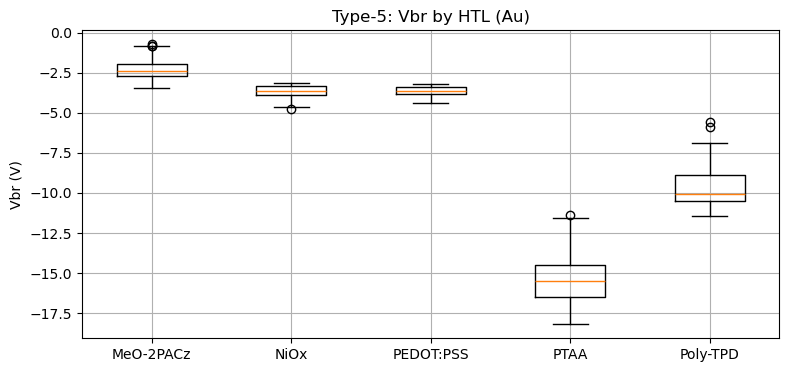

In [11]:
import matplotlib.pyplot as plt
import os

PLOT_DIR = "../results/plots"
os.makedirs(PLOT_DIR, exist_ok=True)

# --- CLEAN DATA JUST IN CASE ---
type5_df["HTL"] = type5_df["HTL"].astype(str).str.strip()
type5_df["Electrode"] = type5_df["Electrode"].astype(str).str.strip()
type5_df["Vbr"] = pd.to_numeric(type5_df["Vbr"], errors="coerce")
type5_df = type5_df.dropna(subset=["Vbr", "HTL", "Electrode"])

# --- PLOT & SAVE ---
for elec in sorted(type5_df["Electrode"].unique()):
    sub = type5_df[type5_df["Electrode"] == elec]

    if sub.empty:
        print(f"Skipping {elec}, no data")
        continue

    htl_groups = [g["Vbr"].values for _, g in sub.groupby("HTL")]
    htl_labels = list(sub.groupby("HTL").groups.keys())

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.boxplot(htl_groups, labels=htl_labels, showfliers=True)
    ax.set_ylabel("Vbr (V)")
    ax.set_title(f"Type‑5: Vbr by HTL ({elec})")
    ax.grid(True)

    out_png = os.path.join(PLOT_DIR, f"type5_vbr_box_by_htl_{elec}.png")
    out_pdf = os.path.join(PLOT_DIR, f"type5_vbr_box_by_htl_{elec}.pdf")

    fig.savefig(out_png, dpi=300, bbox_inches="tight")
    fig.savefig(out_pdf, bbox_inches="tight")

    print("Saved:", out_png)
    print("Saved:", out_pdf)

    plt.show()
    plt.close(fig)